# TIGER (Amazon Beauty) — full pipeline on Kaggle

Ye notebook `TIGER` reproduction repo ko end-to-end chalata hai:
content embeddings -> RQ-VAE -> Semantic IDs -> TIGER transformer -> evaluate.

**Pehle ye zaroor karein:**
1. `TIGER_Recommender_System_updated.zip` ko Kaggle par **Private Dataset** ke roop mein upload karein
   (Add Data -> Upload -> apni zip select karein).
2. Notebook Settings mein **Internet: ON** karein (Amazon reviews/meta download karne ke liye zaroori hai)
   aur **Accelerator: GPU (T4 x2 ya P100)** select karein.
3. Neeche `DATASET_SLUG` variable ko apne uploaded dataset ke naam se replace karein.

**Note on order:** README mein steps ka order thoda misleading hai — `dataloader_beauty.py`
`data/processed/*.jsonl` (sequences) ko pehle se maangta hai (item-filtering ke liye), isliye
hum pehle `preprocess_beauty` chalayenge, phir `dataloader_beauty`. Ye actual code dependency
follow karta hai, README ke listed order se nahi.


In [5]:
import os, shutil, glob

# Poore /kaggle/input ke andar TIGER_Recommender_System dhoondo — chahe kitni bhi nesting ho
src_candidates = glob.glob("/kaggle/input/**/TIGER_Recommender_System", recursive=True)
assert src_candidates, "Abhi bhi nahi mila — `!find /kaggle/input -maxdepth 6` chalakar check karein."
src = src_candidates[0]
dst = "/kaggle/working/tiger"

if os.path.exists(dst):
    shutil.rmtree(dst)
shutil.copytree(src, dst)
os.chdir(dst)
print("Working dir:", os.getcwd())
print(os.listdir("."))

Working dir: /kaggle/working/tiger
['requirements.txt', 'tiger', 'configs', 'README.md']


In [ ]:
# Step 1: Install dependencies
!pip install -q -r requirements.txt

# torch.optim.Adafactor (native) needs torch>=2.5 — Kaggle usually ships a recent
# enough build, but upgrade explicitly to be safe.
import torch
print("torch:", torch.__version__)
if not hasattr(torch.optim, "Adafactor"):
    print("Upgrading torch for native Adafactor support...")
    !pip install -q -U torch --index-url https://download.pytorch.org/whl/cu121
    import importlib
    importlib.reload(torch)
    print("torch (after upgrade):", torch.__version__)

print("CUDA available:", torch.cuda.is_available())


## Stage A — Preprocess Amazon Beauty reviews -> leave-one-out sequences

Reviews dump download karta hai, 5-core filter apply karta hai, aur `data/processed/{train,val,test}.jsonl` likhta hai.
Expected stats: users=22,363 / items=12,101 / mean seq len=8.87 / median=6 (paper Table 6 se match).


In [ ]:
!python -m tiger.scripts.preprocess_beauty --download

## Stage B — Item content embeddings (Sentence-T5)

Meta catalog download karta hai, Stage A ke sequence-items tak filter karta hai (~12k items),
aur Sentence-T5-XXL se content embeddings banata hai. `--download` sirf meta ke liye hai (agar already
maujood hai to skip ho jayega).

Note: `sentence-t5-xxl` bada model hai (~5GB) — pehli baar chalne mein time lagega.


In [ ]:
import yaml

cfg_path = "configs/rqvae/beauty.yaml"
with open(cfg_path) as f:
    cfg = yaml.safe_load(f)

cfg["data"]["embedding_model"] = "sentence-transformers/sentence-t5-base"

with open(cfg_path, "w") as f:
    yaml.dump(cfg, f, default_flow_style=False)

print(cfg["data"])

In [ ]:
!python -m tiger.rqvae.dataloader_beauty --config configs/rqvae/beauty.yaml --download

## Stage C — Train RQ-VAE (paper hyperparameters)

encoder `[512,256,128]` -> latent `32` -> 3-level residual quantizer, codebook size `256` per level,
Adagrad lr=0.1, batch=1024, 20000 epochs, dead-code reinit enabled. Isse `outputs/amazon_beauty_checkpoints/best.pt` banega.

**Sanity check jab ye chal raha ho:** log mein `util=[...]` (codebook utilization per level) dekhte
rahein — paper mein ≥80% usage target hai. Agar kisi level ka usage bahut kam hai (<30-40%),
to codebook collapse ho raha hai — `reinit_every`/`reinit_usage_threshold` config check karein.


In [ ]:
!python -m tiger.rqvae.train --config configs/rqvae/beauty.yaml

In [ ]:
import os
ckpt_dir = "outputs/amazon_beauty_checkpoints"
print(os.listdir(ckpt_dir) if os.path.exists(ckpt_dir) else "Folder nahi mila")

In [ ]:
import json
with open("outputs/amazon_beauty_metrics.json") as f:
    print(json.load(f))

### (Optional but recommended) Inspect the trained Semantic IDs

Codebook utilization, perplexity, aur SID uniqueness fraction print karta hai — final sanity check
RQ-VAE training ke baad, retrieval-stage mein jaane se pehle.


In [ ]:
!python -m tiger.rqvae.generate_sids --config configs/rqvae/beauty.yaml \
    --checkpoint outputs/amazon_beauty_checkpoints/best.pt

## Stage D — Build item <-> Semantic-ID lookup tables

`(c0,c1,c2)` RQ-VAE se aata hai; collision-breaking `c3` yahan assign hota hai
(sequence-items ke subset par). Output: `data/item_to_sid.json`, `data/sid_to_item.json`.


In [ ]:
!python -m tiger.scripts.build_sid_tables \
    --checkpoint outputs/amazon_beauty_checkpoints/best.pt \
    --items-csv  outputs/amazon_beauty_items.csv \
    --embeddings outputs/amazon_beauty_embeddings.npy \
    --sequences-dir data/processed \
    --output-dir   data

## (Recommended) Quick smoke test before the full 200K-step run

4000 steps ka trimmed run — pipeline ke wiring ko verify karta hai (data loading, model forward,
beam-decode eval) bina paper-matching result expect kiye. Agar ye clean chal jaye bina error ke,
tabhi neeche wala full run start karein.


In [ ]:
import sys
sys.path.insert(0, ".")
from tiger.retrieval.train import train_from_config

train_from_config(
    "configs/retrieval/beauty.yaml",
    data_dir="data",
    output_dir="outputs/tiger_beauty_smoketest",
    quick=True,
)

In [ ]:
import yaml

cfg_path = "configs/retrieval/beauty.yaml"
with open(cfg_path) as f:
    cfg = yaml.safe_load(f)

cfg["train"]["total_steps"] = 200000

with open(cfg_path, "w") as f:
    yaml.dump(cfg, f, default_flow_style=False)

print(cfg["train"])

## Stage E — Train the TIGER transformer (full run, paper hyperparameters)

`d_model=128`, `6 heads`, `4+4 encoder/decoder layers`, batch=256, Adafactor peak_lr=0.01
with 10k-step warmup + inverse-sqrt decay, 200K total steps, early stop after 5 evals (25K steps)
without val NDCG@10 improvement.

**Time budget:** Isme kai ghante lag sakte hain (Kaggle GPU session ki single-run limit dhyan mein
rakhein — typically ~9-12h). Agar session cut ho jaye beech mein, is current codebase mein
resume-from-checkpoint logic nahi hai train loop mein — is limitation ko dhyan mein rakhkar,
zaroorat pade to `configs/retrieval/beauty.yaml` mein `total_steps` thoda kam karke pehle chalayein,
ya session timeout se pehle hi training complete ho jaye is hisaab se plan karein.


In [ ]:
!python -m tiger.retrieval.train --config configs/retrieval/beauty.yaml

## Stage F — Evaluate the best checkpoint on the test split (vs. paper)

In [ ]:
!python -m tiger.retrieval.evaluate --checkpoint outputs/tiger_beauty/checkpoints/best.pt

 Save everything for download

Checkpoints + metrics + SID tables ko ek zip mein daal kar `/kaggle/working/` mein rakhte hain
taaki "Output" tab se download ho sake.


In [ ]:
!zip -r /kaggle/working/tiger_beauty_results.zip outputs data/item_to_sid.json data/sid_to_item.json data/processed
print("Saved: /kaggle/working/tiger_beauty_results.zip")

## Stage G — Extra analysis plots (Recall@K and Invalid-IDs@K vs K)

Sir ne 2 additional plots maange hain, jaise paper ke Figure 5/6 style:
1. **Recall@K vs K** for Beauty
2. **Invalid IDs (%) vs K** for Beauty (jaisa paper ka Figure 6)

Ye cell **existing trained checkpoint** (`outputs/tiger_beauty/checkpoints/best.pt`) use karta hai —
koi naya training nahi chahiye, bas alag-alag K (1,5,10,15,20) par evaluation chalega.
Isme ~20-30 min lag sakte hain (5 alag beam-search eval passes, poore test set par).


In [6]:
!pip install -q -r requirements.txt

import torch
print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

torch: 2.10.0+cu128
CUDA available: True


In [7]:
import zipfile, os

zip_path = "/kaggle/input/notebooks/krishn2608/new-1/tiger_beauty_results.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall("/kaggle/working/tiger")

print("Extracted.")
print("Checkpoint exists:", os.path.exists("outputs/tiger_beauty/checkpoints/best.pt"))
print("item_to_sid exists:", os.path.exists("data/item_to_sid.json"))
print("sid_to_item exists:", os.path.exists("data/sid_to_item.json"))

Extracted.
Checkpoint exists: True
item_to_sid exists: True
sid_to_item exists: True


In [8]:
!python -m tiger.scripts.plot_recall_vs_k \
    --checkpoint outputs/tiger_beauty/checkpoints/best.pt \
    --data-dir data \
    --name beauty \
    --ks 1,5,10,15,20 \
    --output-dir outputs/plots

[sweep] evaluating K=1 (beam_width=50)...
[sweep]   recall@1=0.00889862719670885  invalid_rate=0.0
[sweep] evaluating K=5 (beam_width=50)...
[sweep]   recall@5=0.027992666457988643  invalid_rate=8.049009524661272e-05
[sweep] evaluating K=10 (beam_width=50)...
[sweep]   recall@10=0.041854849528238605  invalid_rate=0.00022358359790725755
[sweep] evaluating K=15 (beam_width=50)...
[sweep]   recall@15=0.05415194741313777  invalid_rate=0.0003786015591229561
[sweep] evaluating K=20 (beam_width=50)...
[sweep]   recall@20=0.06314000804900953  invalid_rate=0.0005589589947681439
[sweep] wrote outputs/plots/beauty_recall_vs_k.png
[sweep] wrote outputs/plots/beauty_invalid_vs_k.png
[sweep] wrote outputs/plots/beauty_recall_invalid_vs_k.json


Plots yahan save honge: `outputs/plots/beauty_recall_vs_k.png` aur `outputs/plots/beauty_invalid_vs_k.png`.
Inko display karke dekhte hain:

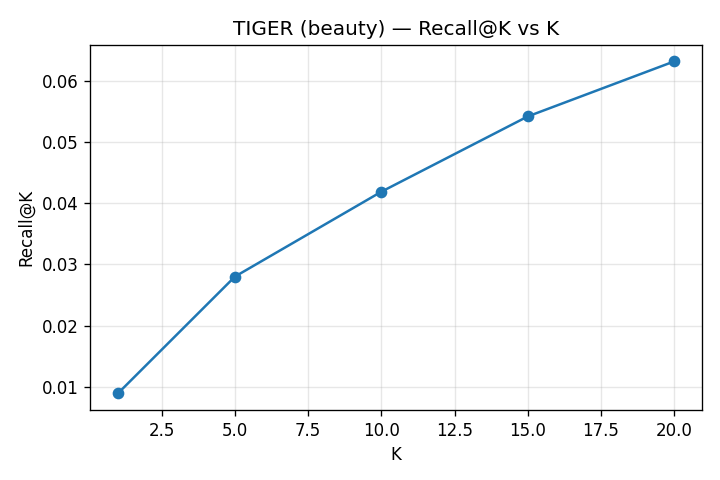

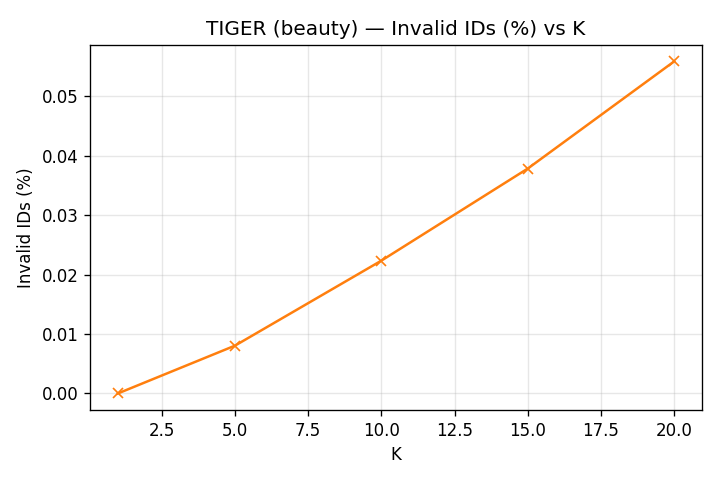

In [9]:
from IPython.display import Image, display
display(Image("outputs/plots/beauty_recall_vs_k.png"))
display(Image("outputs/plots/beauty_invalid_vs_k.png"))

Final zip mein inhe bhi shamil kar lete hain:

In [10]:
!zip -r /kaggle/working/tiger_beauty_extra_plots.zip outputs/plots
print("Saved: /kaggle/working/tiger_beauty_extra_plots.zip")

  adding: outputs/plots/ (stored 0%)
  adding: outputs/plots/beauty_recall_invalid_vs_k.json (deflated 62%)
  adding: outputs/plots/beauty_invalid_vs_k.png (deflated 12%)
  adding: outputs/plots/beauty_recall_vs_k.png (deflated 12%)
Saved: /kaggle/working/tiger_beauty_extra_plots.zip
